Wersja TensorFlow: 2.19.0
Kształt danych wejściowych: (1000, 2)
Kształt celów: (1000, 1)


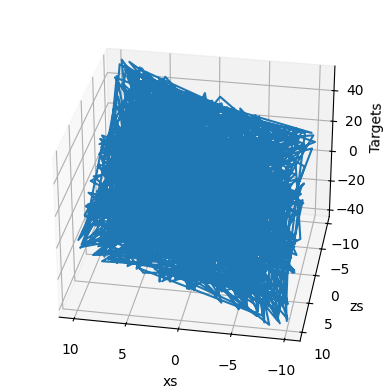


Początkowe wagi i biasy:
Wagi:
 [[-0.07431712]
 [-0.08821493]]
Bias:
 [0.06071106]

Rozpoczęcie uczenia...

Wagi i biasy po nauce:
Wagi:
 [[ 2.00371997]
 [-3.00347809]]
Bias:
 [4.33067122]


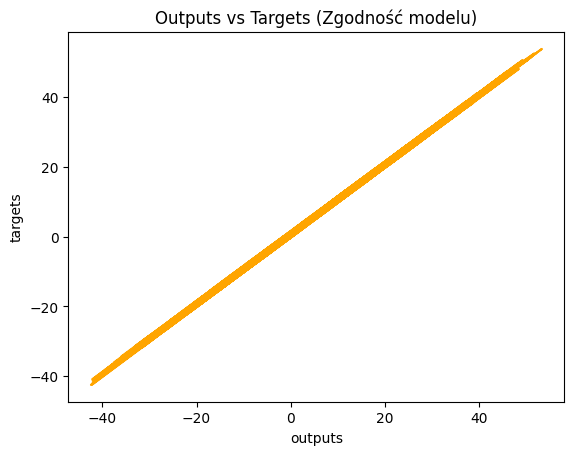

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Wersja TensorFlow:", tf.__version__)

observations = 1000

xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))

inputs = np.column_stack((xs,zs))
print("Kształt danych wejściowych:", inputs.shape)

noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise

np.savez('TF_dataset', inputs=inputs, targets=targets)
print("Kształt celów:", targets.shape)

targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)

print("\nPoczątkowe wagi i biasy:")
print("Wagi:\n", weights)
print("Bias:\n", biases)

targets = targets.reshape(observations,1)
eta = 0.02

print("\nRozpoczęcie uczenia...")
for i in range(100):
    outputs = np.dot(inputs, weights) + biases
    deltas = outputs - targets

    loss = np.sum(deltas ** 2) / 2 / observations

    deltas_scaled = deltas / observations
    weights = weights - eta * np.dot(inputs.T, deltas_scaled)
    biases = biases - eta * np.sum(deltas_scaled)

print("\nWagi i biasy po nauce:")
print("Wagi:\n", weights)
print("Bias:\n", biases)

plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.title('Outputs vs Targets (Zgodność modelu)')
plt.show()